# MVP Análise de Dados e Boas Práticas


Nome: Rafael Pedrosa Vital Gonçalves

Matrícula: 4052025002523

Dataset: https://www.kaggle.com/code/viochristian/salary-prediction

# Descrição do Problema


O dataset escolhido apresenta uma série contendo o salário anual de cargos de TI e suas respectivas informações correlacionadas como tempo de experiência, nível educacional, qualificações e outros.
A intenção final é conseguir treinar um modelo que possa prever o salário de um determinado candidato a uma vaga baseando-se nas características apresentadas antes da contratação.
Além disso, ao final deste trabalho é esperado que possamos evidenciar quais são os fatores mais impactantes no montante final dos salários conhecidos do dataset.

A estruturação do trabalho utilizou como guia da parte de análise exploratória os conceitos descritos no livro Introdução à Estatística para Ciência de Dados(
ESCOVEDO, Tatiana; KALINOWSKI, Marcos; MARQUES, Thiago. Introdução à Estatística para Ciência de Dados: da exploração dos dados à experimentação contínua com exemplos de código em Python e R. São Paulo: Casa do Código, 2021. Edição Kindle.). Por esta razão alguns trechos do livro foram citados para justificar as escolhas codificadas na análise.


# Hipóteses do Problema



1- Quais são os fatores mais determinantes que influenciam o quanto cada empregado ganha?

2- O contexto social (custo de vida e localização) são fatores mais preponderantes que os outros atributos?

3- Até que ponto a qualificação do empregado  pode influenciar nos salários?

4- Onde estão localizados os outliers de salário e porque eles ocorrem?

# Importação das Bibliotecas Necessárias e Carga de Dados

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "job_salary_prediction_dataset.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "nalisha/job-salary-prediction-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
df.head()


# Constants
DATASET_NAME = "nalisha/job-salary-prediction-dataset"
EXACT_COLUMNS = ['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications', 'salary']
TARGET_COL = 'salary'


/tmp/ipykernel_1142/3539600476.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 16.3M/16.3M [00:00<00:00, 99.8MB/s]


#  Análise Exploratória dos dados



## Informações básicas

Escovedo, Kalinowski e Marques (2021, p. 20–21) descrevem alguns dos problemas passíveis de serem identificados na fase exploratória de dados:

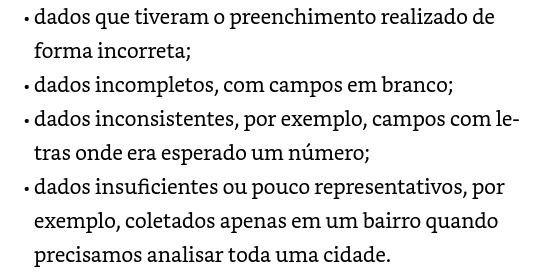

### Tamanho, Tipos e verificação de variáveis não nulas

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


O dataset não apresenta valores nulos e os tipos incialmente parecem estar corretos.

### Dicionário de dados


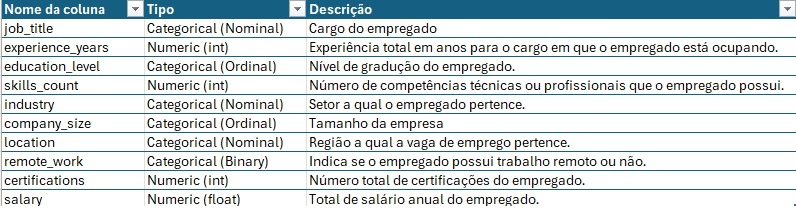

### Linhas duplicadas

In [ ]:
print(f"Linhas Duplicadas: {df.duplicated().sum()}")

Linhas Duplicadas: 0


O dataset não possui valores duplicados

## Medidas de posição, tendência central e dispersão

### Contagem, média, mediana, e medidas separatrizes


In [ ]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


A média do atributo que indica os anos de experiência do empregado foi de aproximadamente 10 anos, enquanto a média dos salários foi de 145.718.08 dólares por ano.
O valores dos salários mais alto e mais baixo registrados estão bastante distantes dos seus respectivos cortes de quartis mais próximos, indicando possíveis outtliers.

### Análise das ocorrências das variáveis categóricas

De acordo com Escovedo, Kalinowski e Marques (2021, p. 31–39), o gráfico de barras e o gráfico de pizza são os mais indicados para análise de variáveis categóricas.

Valores únicos e frequências

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"Variável: {col}")
    print(f"  Número de valores únicos: {df[col].nunique()}")
    print(f"  Valor mais frequente: {df[col].mode()[0]}")
    print("\n")

Variável: job_title
  Número de valores únicos: 12
  Valor mais frequente: Backend Developer


Variável: education_level
  Número de valores únicos: 5
  Valor mais frequente: Master


Variável: industry
  Número de valores únicos: 10
  Valor mais frequente: Finance


Variável: company_size
  Número de valores únicos: 5
  Valor mais frequente: Large


Variável: location
  Número de valores únicos: 10
  Valor mais frequente: Australia


Variável: remote_work
  Número de valores únicos: 3
  Valor mais frequente: No




A análise consiste em verificar o quão heterogêneos ou não cada categoria está registrada no dataset. Os valores encontrados parecem bastante razoáveis, pois não estão muito grandes (muito heterogêneos). Não há necessidade de nenhuma simplificação ou transformação nesse sentido.

Distribuição e análise de balanceamento dos dados

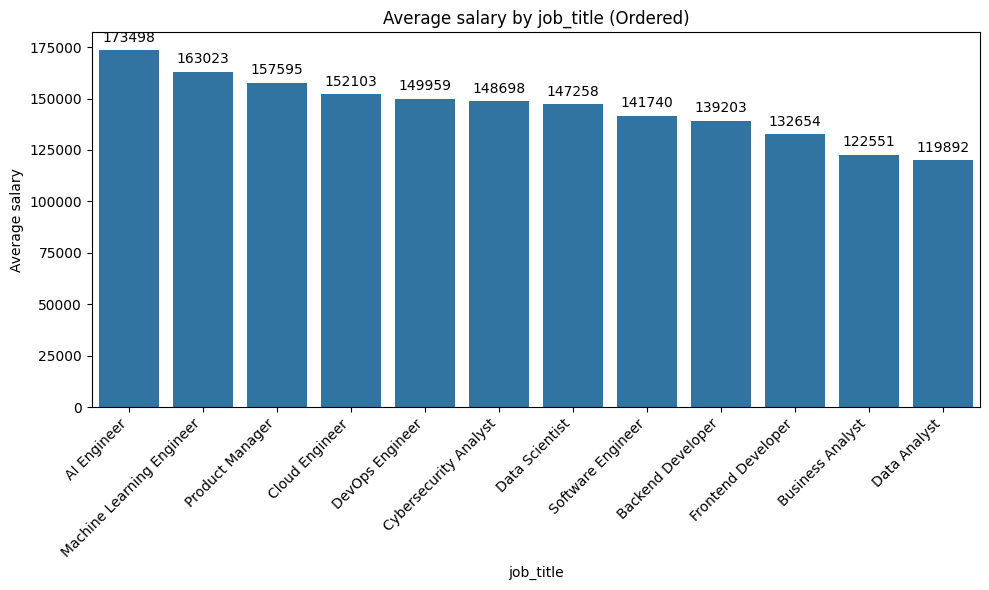

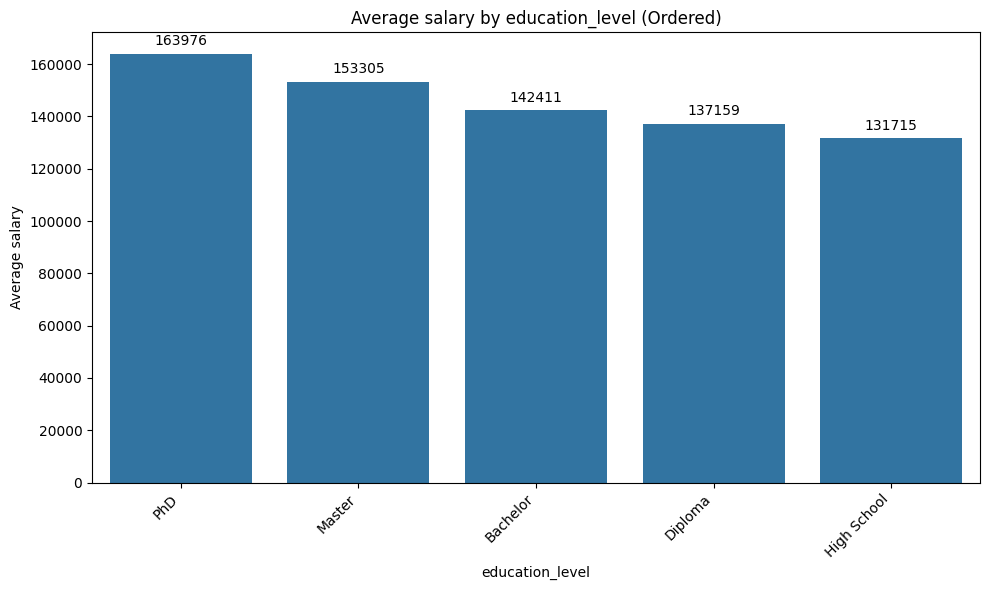

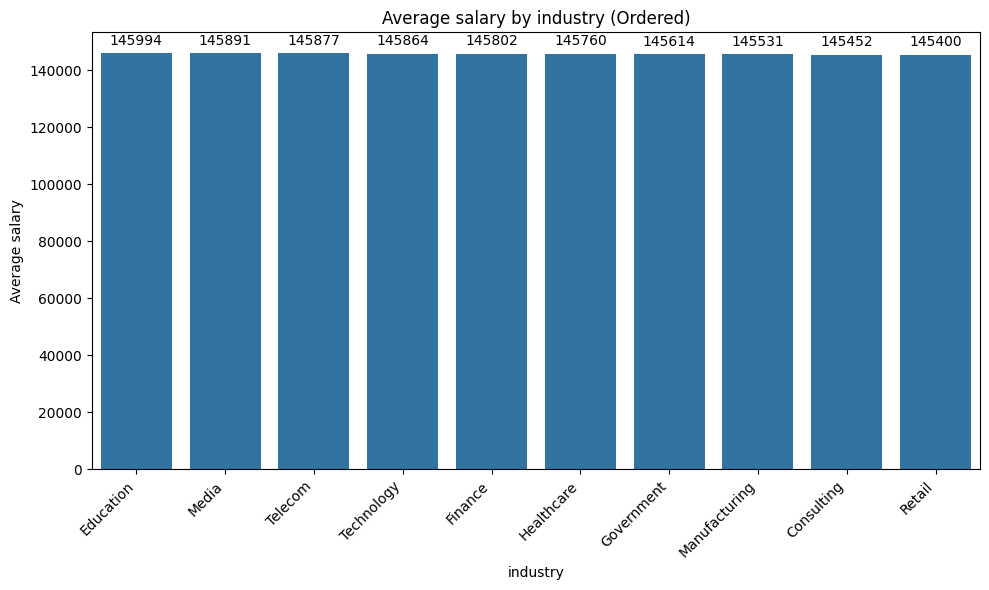

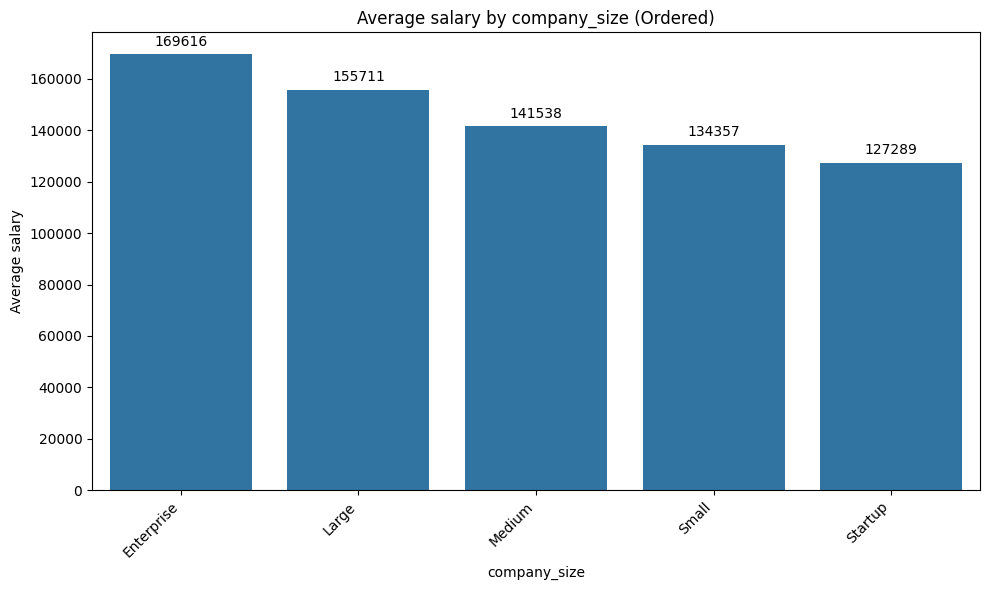

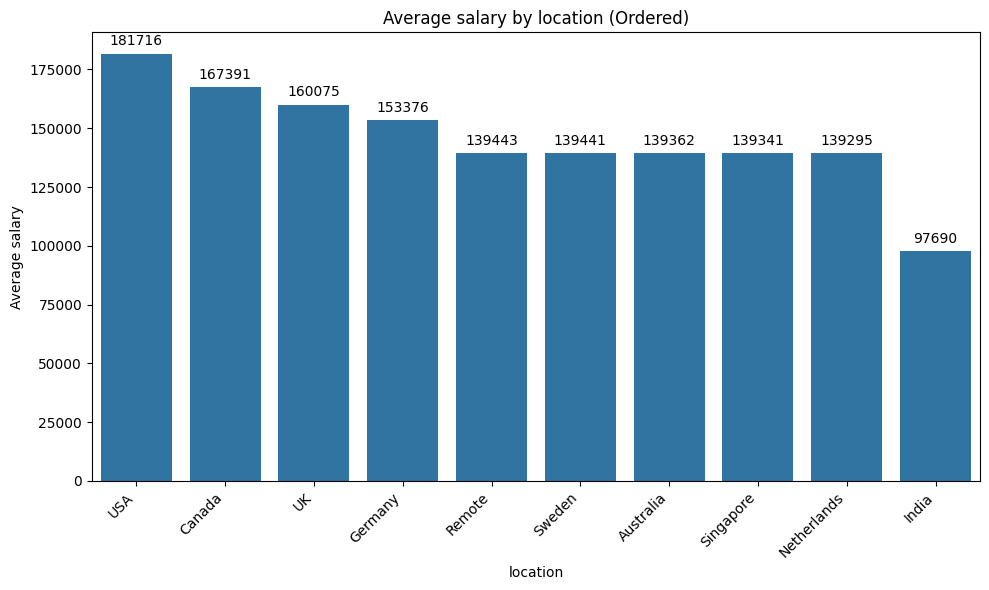

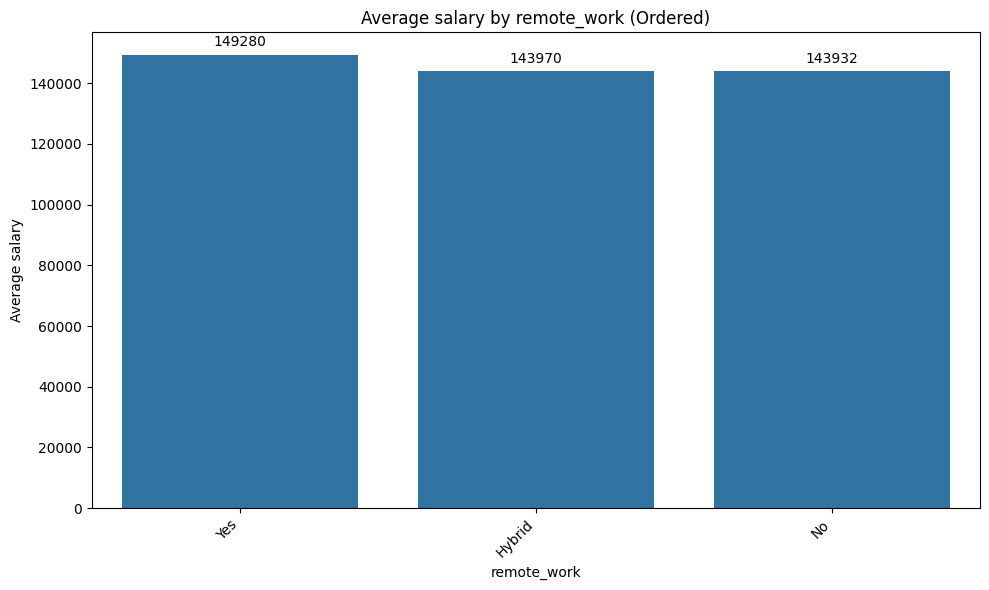

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = df.select_dtypes(include='object').columns
TARGET_COL = 'salary'

for col in categorical_cols:
    # Calculate the average target value for each category and sort them
    ordered_categories = df.groupby(col)[TARGET_COL].mean().sort_values(ascending=False).index

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=col, y=TARGET_COL, data=df, errorbar=None, order=ordered_categories)
    plt.title(f'Average {TARGET_COL} by {col} (Ordered)')
    plt.xlabel(col)
    plt.ylabel(f'Average {TARGET_COL}')
    plt.xticks(rotation=45, ha='right')

    # Add labels to the center of each bar
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.0f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points')

    plt.tight_layout()
    plt.show()

Observações sobre cada categoria analisada:

1- Os cargos de Engenheiro de IA e Engenheiro de machine learning são os cargos mais bem remunerados que estão presentes no dataset, enquanto o cargo de Analista de dados é pior remunerado;

2- Conforme pode ser claramente vista no gráfico ordenado (forma de escada decrescente), ficou evidente que quanto maior o nível educacional do empregado, maior será o seu salário.

3- O segmento a qual o empregado ocupa se mostrou como uma variável com valores mais próximos uns dos outros, sugerindo que essa variável tende a não ser tão determinante para resolução deste problema.

4- O tamanho da empresa se mostrou como um fator importante para determinação do salário, já que teve o mesmo comportamento "em escada" do nível educacional, indicando que quanto maior for a empresa maiores serão os salários;

5- A análise da variável referente a localização do empregado demonstrou que apenas da média entre os países estarem próximas, existe uma grande distância entre os salários executados no país com maior média (EUA) e o país com pior média(Índia). O gráfico indica que o contexto de custo de vida a qual o empregado pertence pode ser determinante no salário que recebe.

6- Os empregos remotos são levemente mais bem remunderados que os empregos híbridos e presenciais, não indicando inicialmente uma grande discrepância entre as diferentes categorias.


### Análise das ocorrências das variáveis numéricas

De acrodo com Escovedo, Kalinowski e Marques (2021, p. 40–44), os gráficos de dispersão, linha e o histograma são os mais recomendados para análises de variáveis númericas.


Histograma - Análise de distribuição e verificação de assimetrias

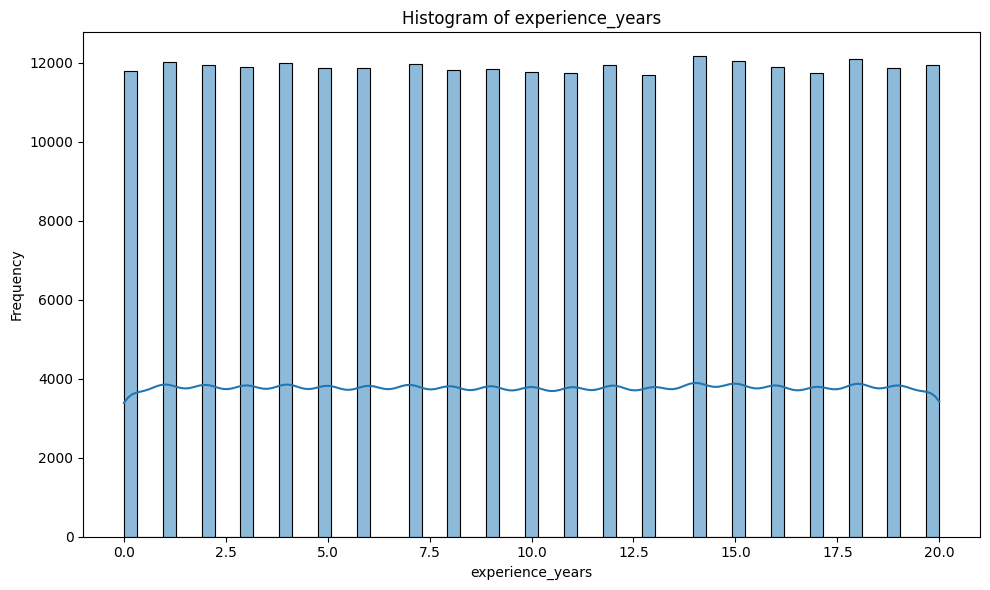

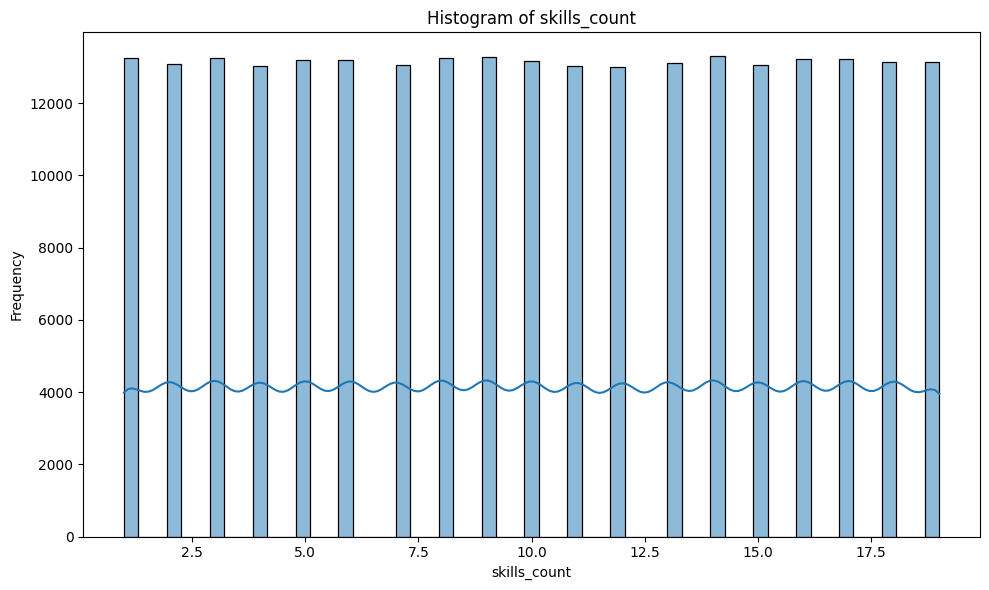

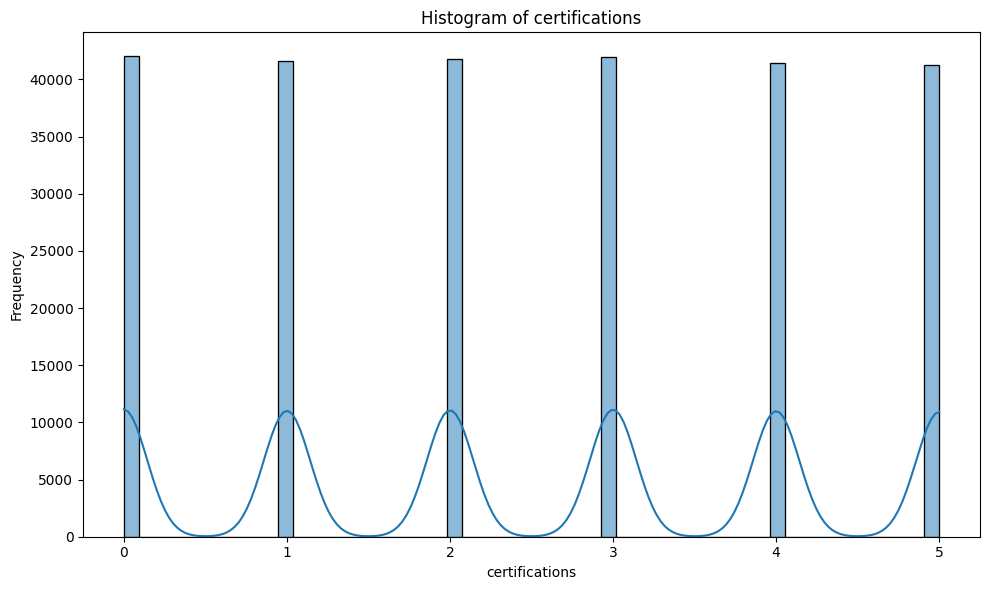

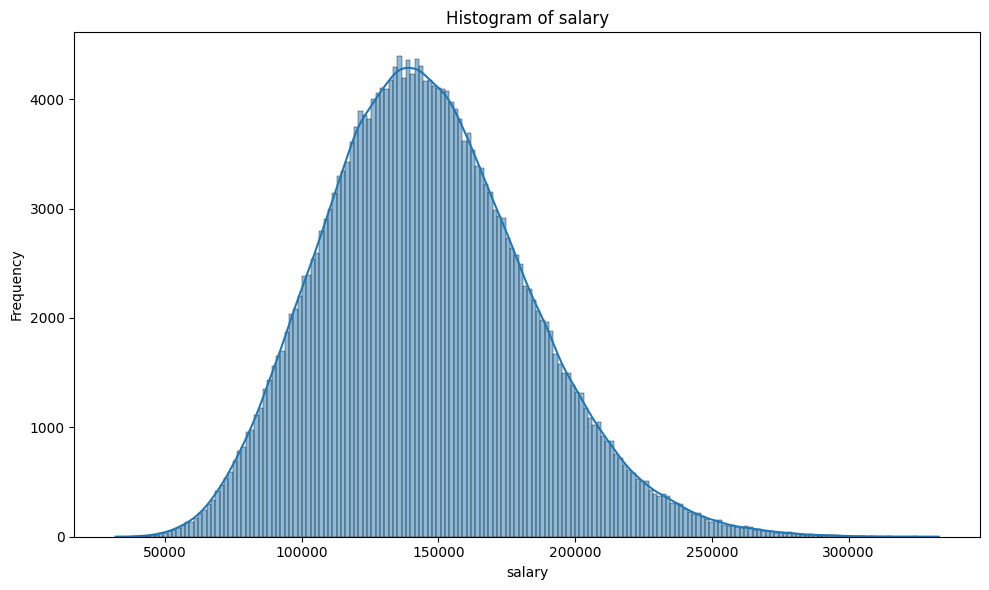

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True) # kde=True adds a Kernel Density Estimate curve
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

### Análise de Outliers

Escovedo, Kalinowski e Marques (2021, p. 82) descrevem o uso do boxplot para análise de outliers: "Para trabalharmos com as medidas de tendência central e de dispersão graficamente, podemos usar o diagrama de caixas (em inglês, boxplot), que é uma representação gráfica da distribuição dos dados. Esse diagrama nos dá informação da assimetria da distribuição, da presença de outliers (valores atípicos) e da variabilidade dos dados por meio da amplitude (Máx-Min)."

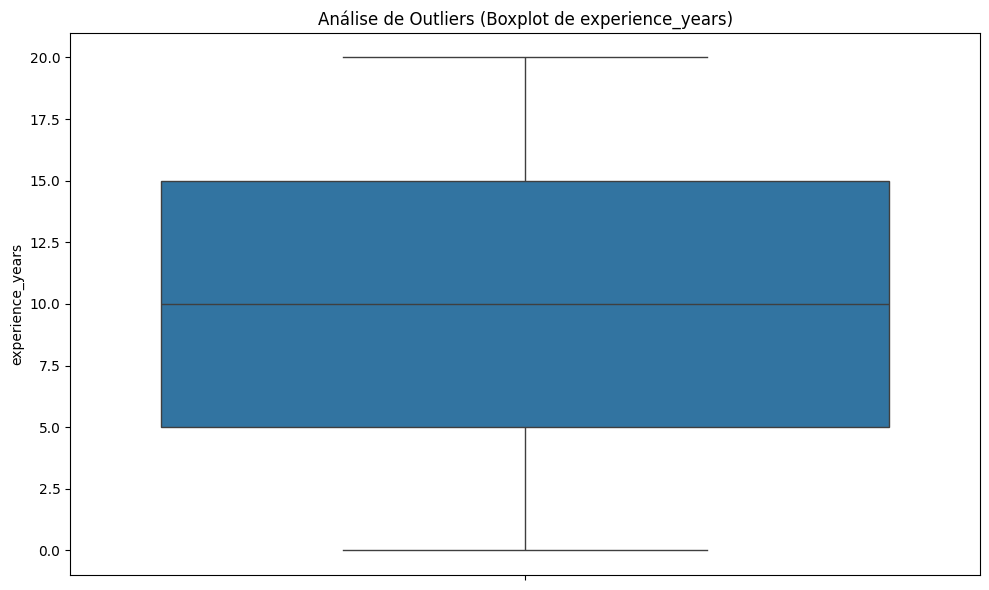

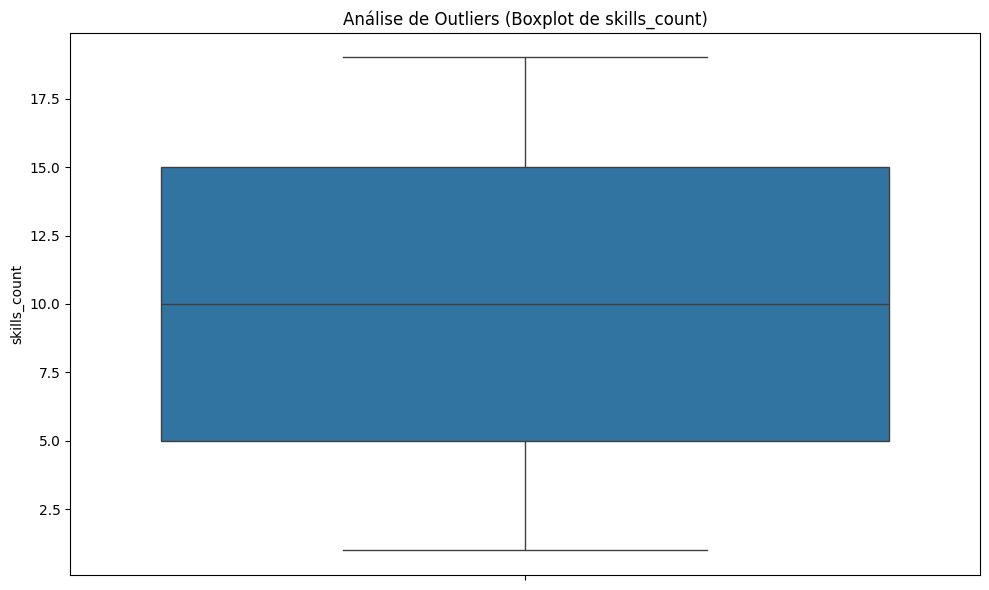

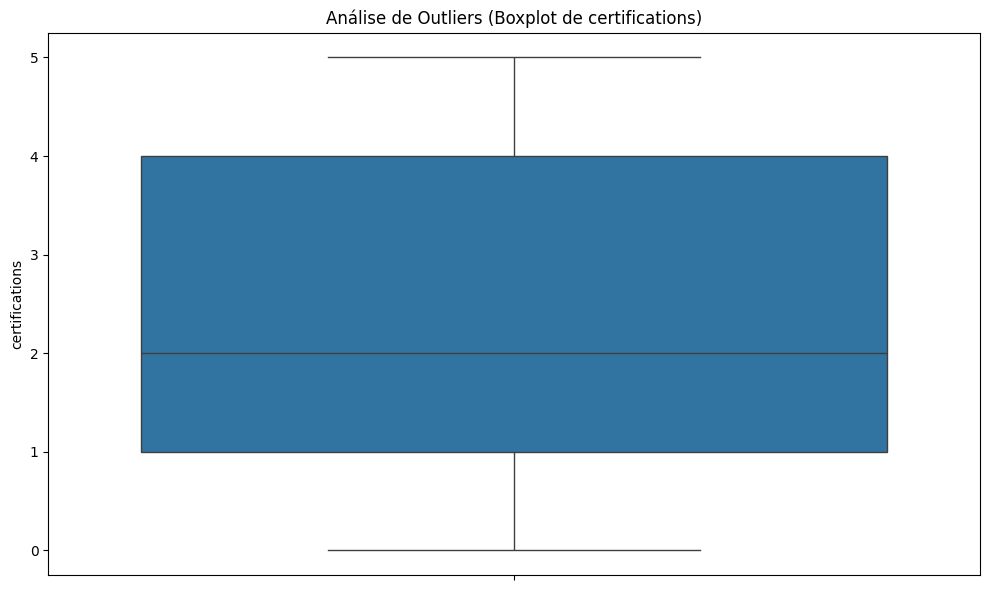

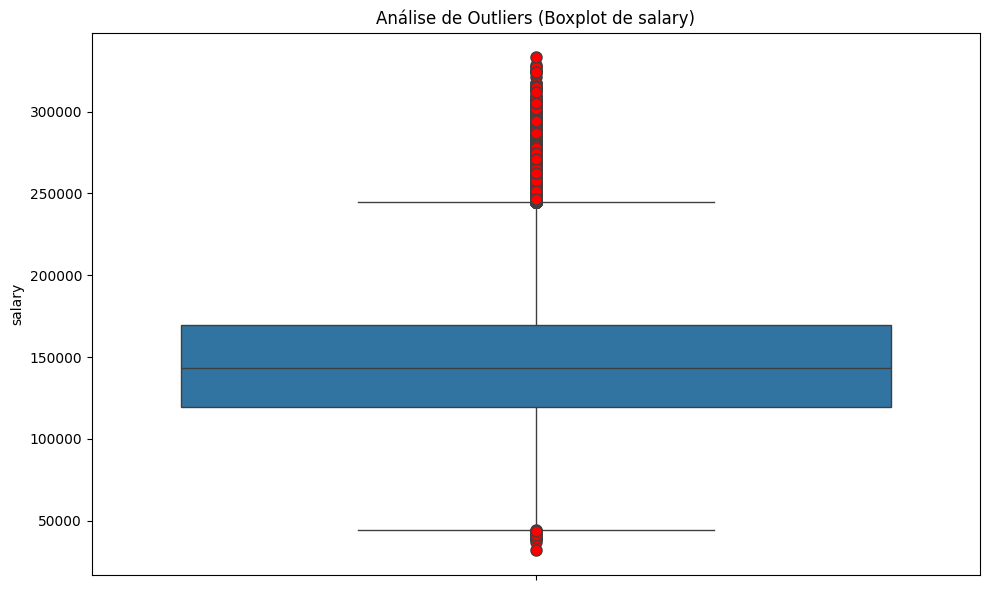

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    plt.figure(figsize=(10, 6))

    # Define flier properties to highlight outliers
    flierprops = dict(marker='o', markerfacecolor='red', markersize=8, linestyle='none')

    sns.boxplot(y=df[col], flierprops=flierprops)
    plt.title(f'Análise de Outliers (Boxplot de {col})')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

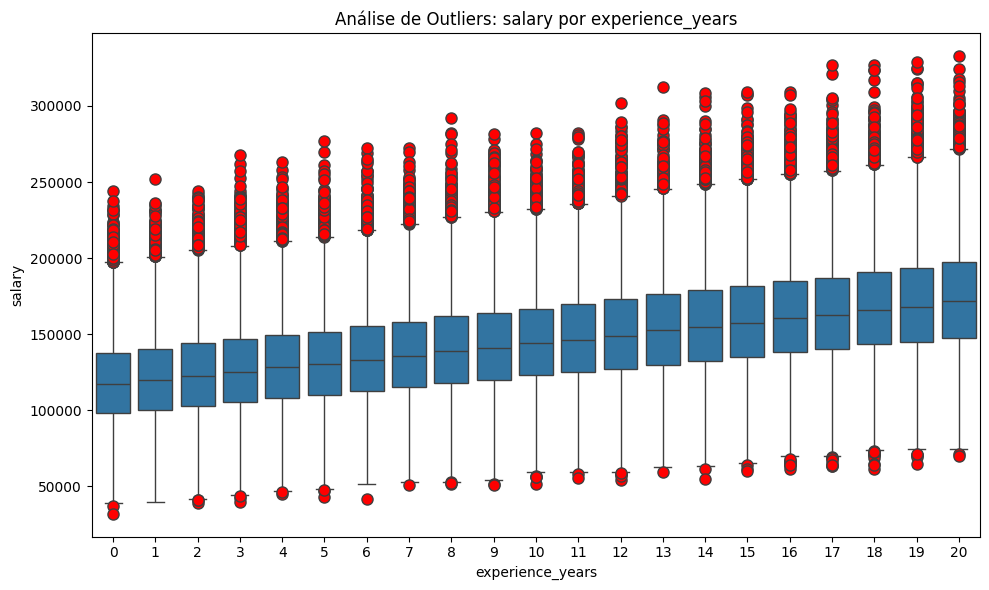

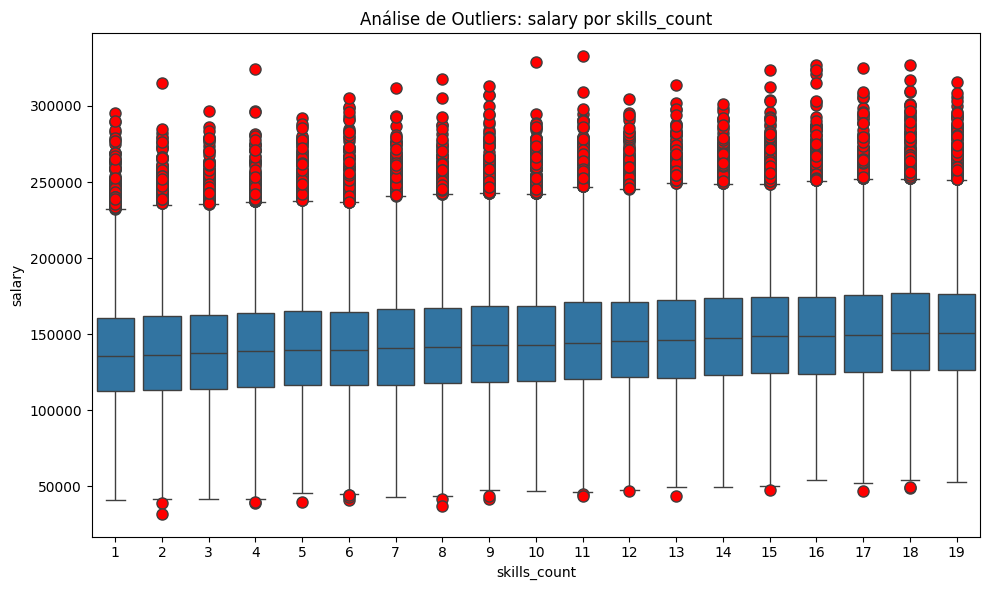

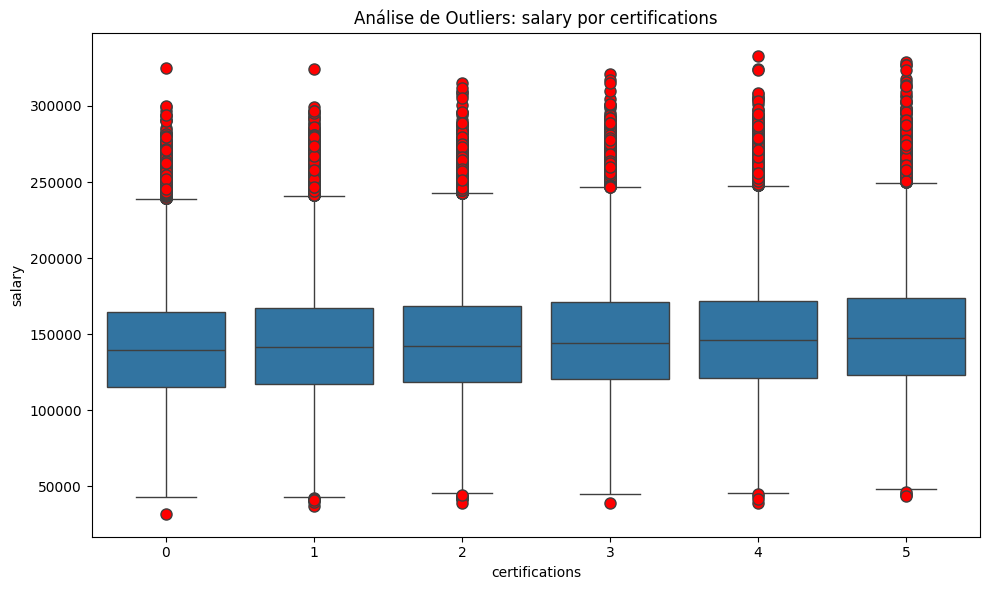

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
TARGET_COL = 'salary'

for col in numerical_cols:
    if col != TARGET_COL: # Avoid plotting salary against itself in this manner
        plt.figure(figsize=(10, 6))

        # Define flier properties to highlight outliers
        flierprops = dict(marker='o', markerfacecolor='red', markersize=8, linestyle='none')

        sns.boxplot(x=df[col], y=df[TARGET_COL], flierprops=flierprops)
        plt.title(f'Análise de Outliers: {TARGET_COL} por {col}')
        plt.xlabel(col)
        plt.ylabel(TARGET_COL)
        plt.tight_layout()
        plt.show()

Contagem de ocorrências

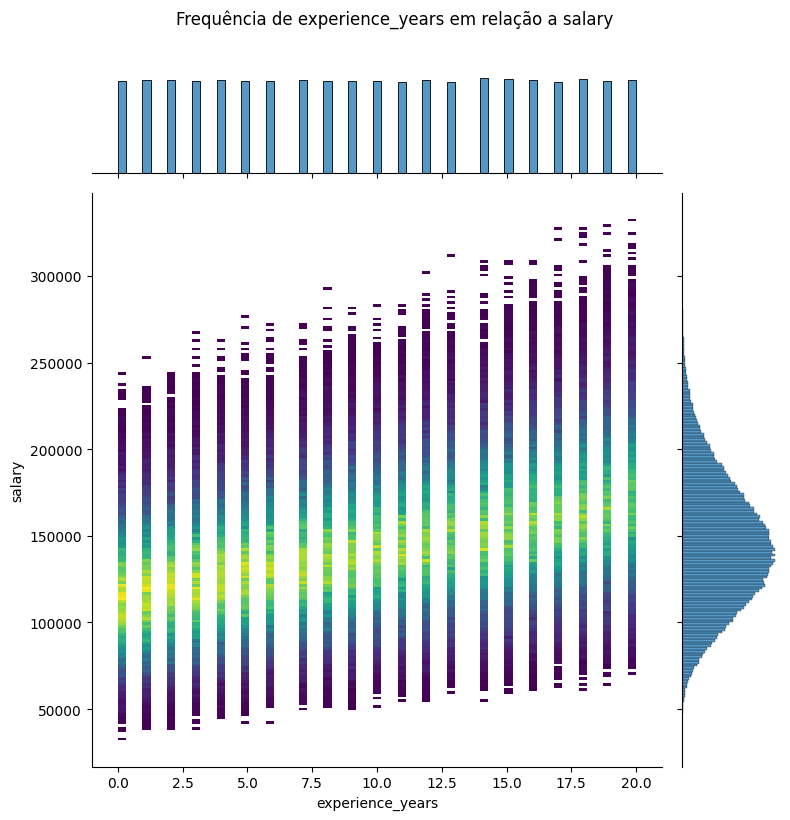

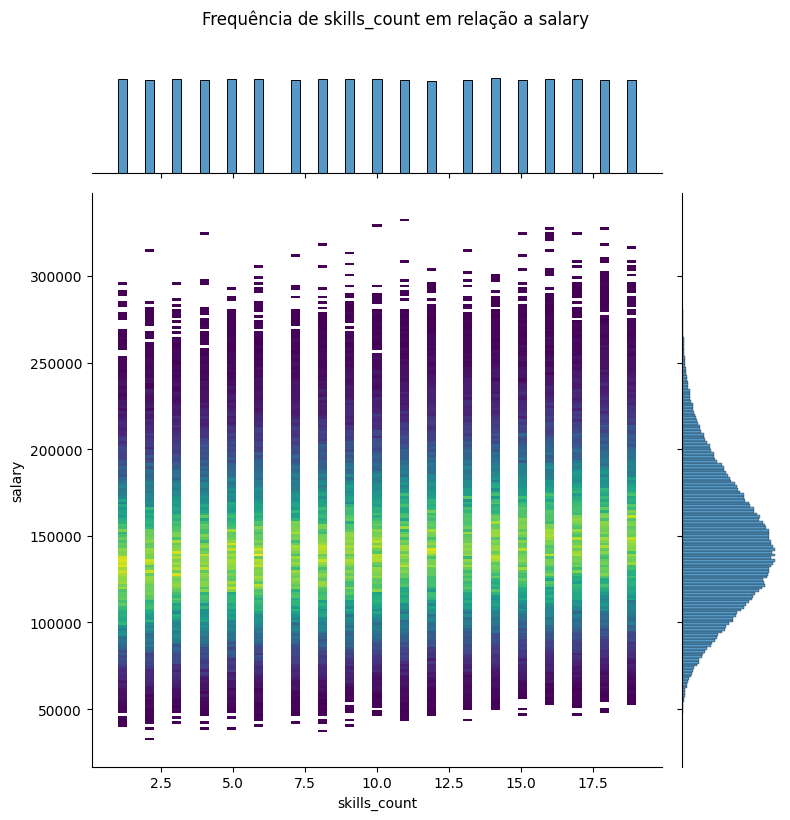

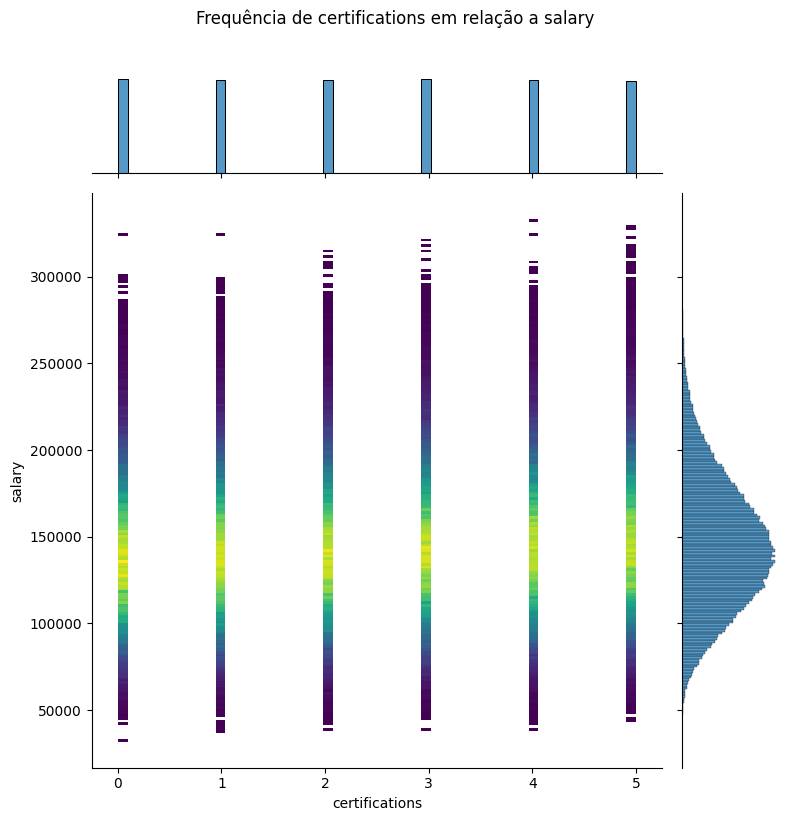

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
TARGET_COL = 'salary'

for col in numerical_cols:
    if col != TARGET_COL:
        sns.jointplot(x=col, y=TARGET_COL, data=df, kind='hist', cmap='viridis', height=8)
        plt.suptitle(f'Frequência de {col} em relação a {TARGET_COL}', y=1.02) # Adjust suptitle position
        plt.tight_layout()
        plt.show()

### Observações sobre análise das variáveis numéricas



1 - Observou-se que existe um númerico significamente grande de outliers de salário entre pessoas com baixa experiência (0 ou 1 ano de experiência) e com número baixo de qualificações;  Talvez isso possa ser explicado pela diferença exibida na análise de variável categórica de localização (diferença entre EUA e India).

/tmp/ipykernel_1142/3298594247.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Group', y='Average Salary', data=comparison_df, palette='viridis')


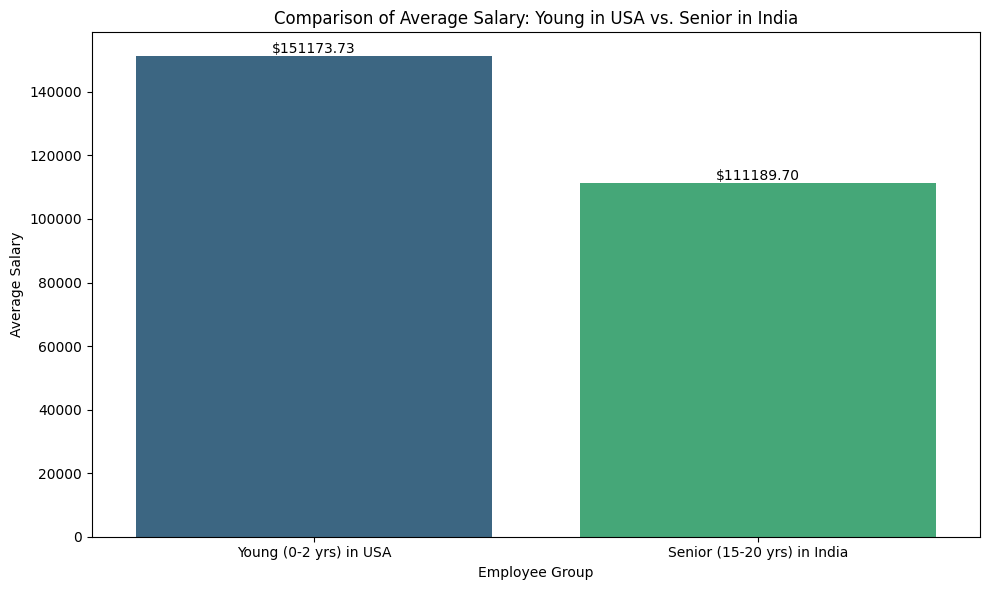

Average salary for young (0-2 years experience) in USA: $151173.73
Average salary for senior (15-20 years experience) in India: $111189.70


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define conditions for "young with little experience in USA"
young_usa_condition = (df['location'] == 'USA') & (df['experience_years'] <= 2)
young_usa_salary = df[young_usa_condition]['salary'].mean()

# Define conditions for "senior employees in India"
senior_india_condition = (df['location'] == 'India') & (df['experience_years'] >= 15)
senior_india_salary = df[senior_india_condition]['salary'].mean()

# Create a DataFrame for plotting
comparison_df = pd.DataFrame({
    'Group': ['Young (0-2 yrs) in USA', 'Senior (15-20 yrs) in India'],
    'Average Salary': [young_usa_salary, senior_india_salary]
})

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Group', y='Average Salary', data=comparison_df, palette='viridis')
plt.title('Comparison of Average Salary: Young in USA vs. Senior in India')
plt.ylabel('Average Salary')
plt.xlabel('Employee Group')

# Add salary values on top of the bars
for index, row in comparison_df.iterrows():
    plt.text(row.name, row['Average Salary'], f'${row['Average Salary']:.2f}', color='black', ha="center", va='bottom')

plt.tight_layout()
plt.show()

print(f"Average salary for young (0-2 years experience) in USA: ${young_usa_salary:.2f}")
print(f"Average salary for senior (15-20 years experience) in India: ${senior_india_salary:.2f}")

2 - A análise de distribuição do número de certificações mostrou-se bastante estável em relação a outras variáveis. Pode-se inferir que se consideramos apenas o número de certificações, esse fator não é tão decisivo de modo isolado em relação ao montante do salário. Quanto aos valores extremos, não esperava um grupo tão grande de altos salários relacionados a pessoas sem nenhuma certificação;

3- Apesar de não ser tão grande como os anos de experiência é possível perceber pela sobreposição dos bloxplots que o salário aumenta a medida que o número de qualificações são maiores;

## Matriz de Correlação

De acordo com Escovedo, Kalinowski e Marques (2021, p. 20–21), os principais propósitos da análise de correlação são : Entender a relação entre as variáveis; Facilitar a seleção de características; Validar modelos;Detecção de multicolinearidade; e ser útil à análise exploratória.

Na etapa abaixo selecionei o método de calculo da correlação com o método de Pearson (default para o Pandas):


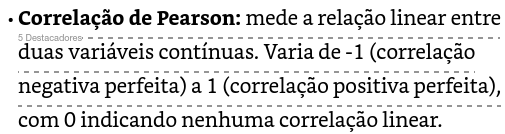

**(ESCOBEDO; KALINOWSKI; MARQUES, 2021, p. 50)*

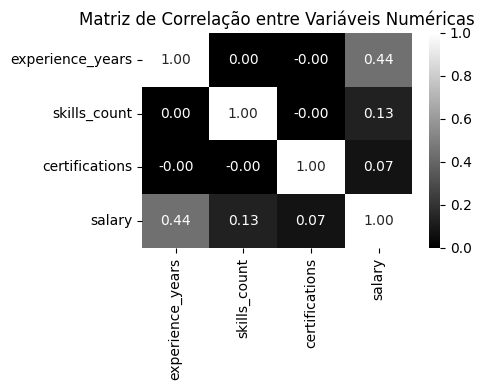

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation matrix
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='gray', fmt='.2f')
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.tight_layout()
plt.show()

# Pré-Processamento de dados

Segundo Provost e Fawcett, o pré-processamento “melhora a qualidade dos dados de entrada, reduz ruídos e aumenta a capacidade do modelo de identificar padrões úteis para previsão” (PROVOST; FAWCETT, 2018).

## Separação das amostras de teste e treino

In [ ]:
df_atributos = df.drop(columns='salary')
df_salario = df['salary']

In [ ]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df_atributos_treino, df_atributos_teste, df_salario_treino, df_salario_teste = train_test_split(df_atributos, df_salario, test_size=0.2, random_state=42)

In [ ]:
print("Atributos - Treino:", df_atributos_treino.shape)
print("Atributos - Teste:", df_atributos_teste.shape)
print("Salario - Treino:", df_salario_treino.shape)
print("Salario - Teste:", df_salario_teste.shape)

Atributos - Treino: (200000, 9)
Atributos - Teste: (50000, 9)
Salario - Treino: (200000,)
Salario - Teste: (50000,)


## Encoding dos atributos

### Variáveis cardinais
Por possuirem  várias diferentes categorias que indicam proporcionalidade contínua, para os campos tamanho da empresa (company_size) e nível educacional (education_level)  serão atribuidos numeros de 0 a n do menor para o maiotr. Para prevenir vazamento de dados, a transformação com fit do modelo só será aplicada exclusivamente no dataset de teste.

In [ ]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
X = df.drop(columns='salary')
y = df['salary']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dimensi X_train:", X_train.shape)
print("Dimensi y_train:", y_train.shape)
print("Dimensi X_test:", X_test.shape)
print("Dimensi y_test:", y_test.shape)

Dimensi X_train: (200000, 9)
Dimensi y_train: (200000,)
Dimensi X_test: (50000, 9)
Dimensi y_test: (50000,)


In [ ]:
categories = [['Startup', 'Small', 'Medium', 'Large', 'Enterprise']]
ord_encod_company_size = OrdinalEncoder(categories=categories)
X_train['company_size'] = ord_encod_company_size.fit_transform(X_train[['company_size']])
X_test['company_size'] = ord_encod_company_size.transform(X_test[['company_size']])


categories = [['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']]
ord_encod_edu_level = OrdinalEncoder(categories=categories)
X_train['education_level'] = ord_encod_edu_level.fit_transform (X_train[['education_level']])
X_test['education_level'] = ord_encod_edu_level.transform (X_test[['education_level']])

In [ ]:
X_train.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications
75381,Machine Learning Engineer,4,Diploma,14,Technology,2.0,India,Yes,5
65569,Backend Developer,1,PhD,6,Consulting,3.0,Sweden,Yes,1
163473,Backend Developer,16,High School,3,Manufacturing,2.0,Canada,No,1
90518,Data Analyst,4,High School,18,Finance,0.0,UK,Hybrid,4
138866,Backend Developer,7,Diploma,8,Retail,2.0,Germany,No,0


### Colunas nominais
Diferentemente do campo de tamanho da empresa onde o valor codificado ordinário é proporcional ao tamanho da empresa , nas colunas de cargo (job_title), segmento (industry), location (localização) e trabalho remoto (remote_work) não existe essa correlação. Portanto para esses casos de categorias nominais, será aplicada a técnica de One-hot encoding, transformando para categoria em uma nova coluna com váriável binária.

In [ ]:
obj_columns = X_train.select_dtypes(include='object').columns
obj_columns

Index(['job_title', 'industry', 'location', 'remote_work'], dtype='object')

In [ ]:
ohe=OneHotEncoder(handle_unknown='ignore', sparse_output=False)
x_train_encoded_array = ohe.fit_transform(X_train[obj_columns])
new_column_names = ohe.get_feature_names_out()

df_encoded = pd.DataFrame(x_train_encoded_array, columns=new_column_names, index=X_train.index)
X_train.drop(columns = obj_columns, inplace=True)
X_train = pd.concat([X_train, df_encoded], axis=1)
X_train.columns = X_train.columns.str.replace(" ", "_").str.lower()
display(X_train)

,experience_years,education_level,skills_count,company_size,certifications,job_title_ai_engineer,job_title_backend_developer,job_title_business_analyst,job_title_cloud_engineer,job_title_cybersecurity_analyst,...,location_india,location_netherlands,location_remote,location_singapore,location_sweden,location_uk,location_usa,remote_work_hybrid,remote_work_no,remote_work_yes
75381,4,1.0,14,2.0,5,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
65569,1,4.0,6,3.0,1,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
163473,16,0.0,3,2.0,1,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
90518,4,0.0,18,0.0,4,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
138866,7,1.0,8,2.0,0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,3,1.0,5,0.0,0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
103694,7,2.0,6,4.0,4,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
131932,6,4.0,6,3.0,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
146867,7,0.0,8,2.0,2,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


### MinMaxScaler
Nesta etapa iremos normalizar os dados numéricos, trazendo todos para a escala entre 0 e 1. isso garante equidade de dimensionalidade, trazendo maior isonomia quanto ao impacto de cada variável no target final.

In [ ]:
num_columns = ['experience_years', 'skills_count', 'certifications', 'education_level', 'company_size']
scaler = MinMaxScaler()


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 75381 to 121958
Data columns (total 40 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   experience_years                     200000 non-null  int64  
 1   education_level                      200000 non-null  float64
 2   skills_count                         200000 non-null  int64  
 3   company_size                         200000 non-null  float64
 4   certifications                       200000 non-null  int64  
 5   job_title_ai_engineer                200000 non-null  float64
 6   job_title_backend_developer          200000 non-null  float64
 7   job_title_business_analyst           200000 non-null  float64
 8   job_title_cloud_engineer             200000 non-null  float64
 9   job_title_cybersecurity_analyst      200000 non-null  float64
 10  job_title_data_analyst               200000 non-null  float64
 11  job_title_data

In [ ]:
X_train[num_columns] = scaler.fit_transform(X_train[num_columns])


In [ ]:
X_test[num_columns] = scaler.transform(X_test[num_columns])

X_train.head()

,experience_years,education_level,skills_count,company_size,certifications,job_title_ai_engineer,job_title_backend_developer,job_title_business_analyst,job_title_cloud_engineer,job_title_cybersecurity_analyst,...,location_india,location_netherlands,location_remote,location_singapore,location_sweden,location_uk,location_usa,remote_work_hybrid,remote_work_no,remote_work_yes
75381,0.20,0.25,0.722222,0.50,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
65569,0.05,1.00,0.277778,0.75,0.2,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
163473,0.80,0.00,0.111111,0.50,0.2,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
90518,0.20,0.00,0.944444,0.00,0.8,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
138866,0.35,0.25,0.388889,0.50,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## Avaliação das variáveis antes do treino do modelo
Antes de prosseguir para o treinamento do modelo definitivo iremos verificar a importância das variáveis com algorítimos simples, apenas para guiar a engenharia das features. Esta etapa pode ajudar a identificar se alguma feature é irrelevante para o modelo  antes das melhorias na fase de tunning.

,features,importances
0,experience_years,0.198271
1,location_india,0.181792
2,company_size,0.169297
3,education_level,0.096901
4,location_usa,0.076173
5,job_title_ai_engineer,0.051820
6,job_title_data_analyst,0.036627
7,job_title_business_analyst,0.035587
8,location_canada,0.034555
9,skills_count,0.021654


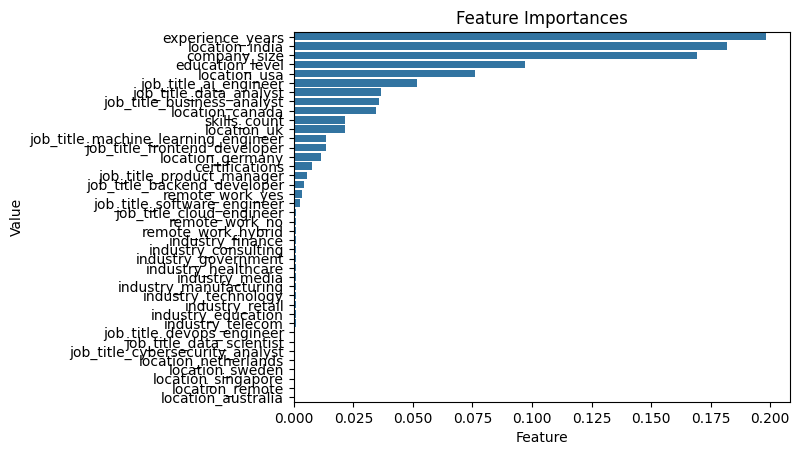

In [ ]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

features_importances = pd.DataFrame({
    "features": X_train.columns,
    "importances": rf.feature_importances_
}).sort_values(by="importances", ascending=False).reset_index(drop=True)
display(features_importances)

sns.barplot(data=features_importances, y="features", x="importances")
plt.title("Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.show()

### Respondendo nossas hipóteses


1- Quais são os fatores mais determinantes que influenciam o quanto cada empregado ganha?

Ficou evidente pelas demonstrações gráficas e resultados de importância que o atribuito que se refere a experiência do funcionário é o que mais determina o seu salário. Com menor importância, mas ainda afetando diretamente o salário estão o tamanho da empresa e o nível educacional do empregado. Outras variáveis impactantes se referem a localização dos funcionários, conforme descrita na hipótese a seguir.


2- O contexto social (custo de vida e localização) são fatores mais preponderantes que os outros atributos?

Conforme foi aventado e demonstrado nas observações de descrição das váriáveis a discrepância entre os salários realizados nos EUA e na India se mostraram altamente relevantes na resolução do problema. Podemos inferir que o contexto social e o custo de vida relacionada a localização é um fator crítico para o resultado final.


3- Até que ponto a qualificação do empregado  pode influenciar nos salários?
COntrariando o que era esperado no início da análise, tanto a contagem de qualificações como a quantidade de certificados mostraram-se pouco influentes no resultado final.


4- Onde estão localizados os outliers de salário e porque eles ocorrem?

Foram encontradas amostras parecidas de outliers de salário para cada categoria, destacando-se:

- Pessoas com pouco experiência e altos salários podem estar relacionadas ao contexto social em que estão inseridos, mas também podem se referir a alguns poucos jovens com capacidade extraordinárias ou jovens donos de empresas recem-criadas e que atuam como força de trabalho nesses empreendimentos.

- Pessoas com alto salário e pouca qualificação podem ser explicados por empregados hiper especializados em um único assunto.



# Conclusão




A análise e pré-processamento do dataset de salários associados a cargos de TI proporcionou um bom exercício para exemplificar alguns dos passos e cuidados que precisam ser considerados em um projeto de ciência de dados. Apesar do dataset apresentar um assunto relativamente comum, alguns insights foram surpreendentes e puderam ser comprovados atraves da aplicação das técnicas e demonstrações visuais aprendidas durante a Sprint de Análise de dados e boas práticas.
Apesar do storytelling ter sido interrompido após a fase de pré-processamento de dados, todos os artefatos gerados podderão ser utilizados em uma primeira rodada de treinamento para geração de um modelo para previsão do salário.
Certamente a evolução para esta etapa poderá gerar novas necessidades de análises para que o fator de acerto do modelo possa ser melhorado posteriormente.

## Bibliografia

ESCOVEDO, Tatiana; KALINOWSKI, Marcos; MARQUES, Thiago. Introdução à Estatística para Ciência de Dados: da exploração dos dados à experimentação contínua com exemplos de código em Python e R. São Paulo: Casa do Código, 2021. Edição Kindle.

FAWCETT, T.; PROVOST, F. Data science para negócios: o que você precisa saber sobre mineração de dados e pensamento analítico de dados. Rio de Janeiro: Alta Books, 2018.